TP2 ML Régression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler


In [6]:
# Création du dataframe avec les données de measurements.csv

df2 = pd.read_csv("measurements.csv", sep=",")
df2.columns = df2.columns.str.strip()  # supprime espaces/tabs parasites dans les noms de colonnes
df2.columns = ["x","y"]
print("Shape:", df2.shape)
print("\nFirst rows:\n", df2.head())    

Shape: (16, 2)

First rows:
      x    y
0  0.0  0.5
1  1.0  0.9
2  2.0  1.6
3  3.0  2.3
4  4.0  2.2


Question 7 – Load and plot the dataset

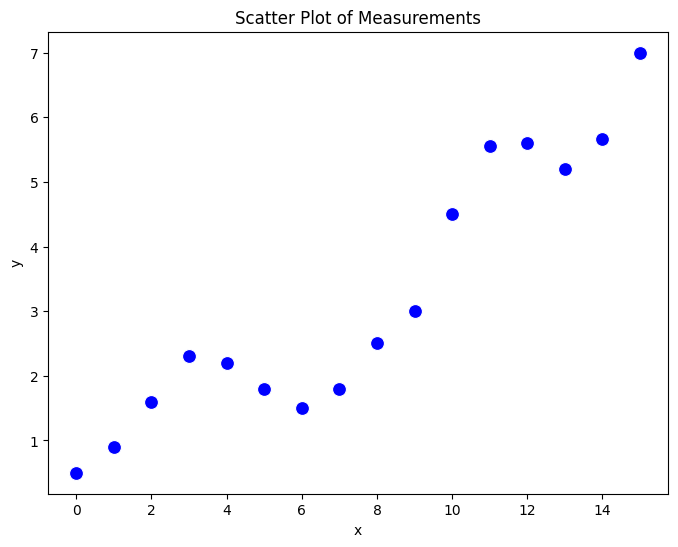

In [10]:
# Visualisation des données
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df2, x="x", y="y", color="blue", s=100)
plt.title("Scatter Plot of Measurements")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Mean Squared Error: 0.4887
R² Score: 0.8736


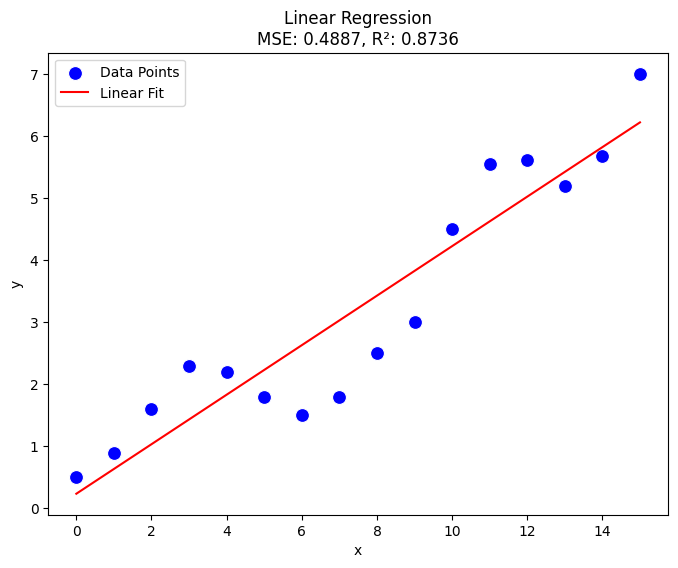

In [14]:
# Régression linéaire
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(df2[["x"]], df2["y"])
y_pred = model.predict(df2[["x"]])

# Mean Squared Error and R² Score
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(df2["y"], y_pred)
print(f"Mean Squared Error: {mse:.4f}")
r2 = model.score(df2[["x"]], df2["y"])
print(f"R² Score: {r2:.4f}")

# Visualisation de la régression linéaire avec l'erreur et le coefficient de détermination

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df2, x="x", y="y", color="blue", s=100, label="Data Points")
plt.plot(df2["x"], y_pred, color="red", label="Linear Fit")
plt.title(f"Linear Regression\nMSE: {mse:.4f}, R²: {r2:.4f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()  

Question 8 : Polynomial regression

Degré  2 — MSE: 0.3472   R²: 0.9102
Degré 10 — MSE: 0.0066   R²: 0.9983
Degré 25 — MSE: 0.1817   R²: 0.9530


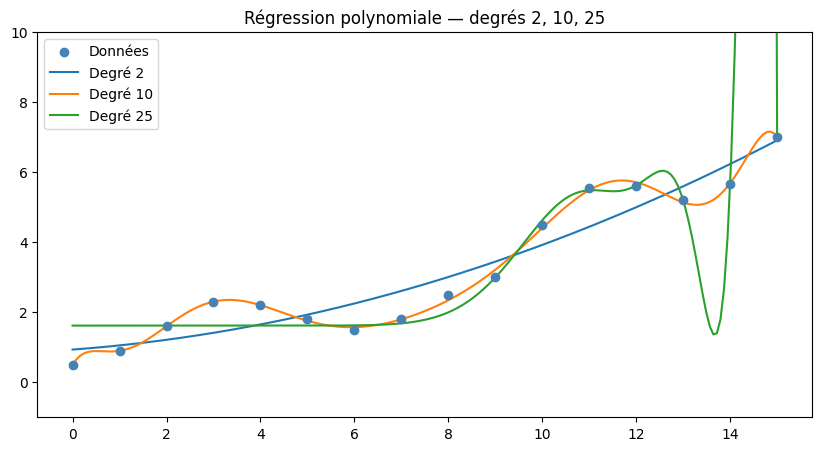

In [32]:
from sklearn.preprocessing import PolynomialFeatures

X_reg = df2[["x"]].values.reshape(-1, 1)
y_reg = df2["y"].values

degrees = [2, 10, 25]
x_plot = np.linspace(0, 15, 200).reshape(-1, 1) # pour une courbe lisse

plt.figure(figsize=(10, 5))
plt.scatter(X_reg, y_reg, color="steelblue", zorder=5, label="Données")

for deg in degrees:
    # Créer les features polynomiales (x, x², x³, ...)
    poly = PolynomialFeatures(degree=deg)
    X_poly = poly.fit_transform(X_reg)

    # Entraîner
    poly_model = LinearRegression()
    poly_model.fit(X_poly, y_reg)

    # Métriques
    y_pred_poly = poly_model.predict(X_poly)
    mse_p = mean_squared_error(y_reg, y_pred_poly)
    r2_p  = poly_model.score(X_poly, y_reg)
    print(f"Degré {deg:2d} — MSE: {mse_p:.4f}   R²: {r2_p:.4f}")

    # Tracer la courbe avec np.polyval comme indiqué dans le sujet
    p  = np.append(np.flip(poly_model.coef_[1:]), poly_model.intercept_)
    y3 = np.polyval(p, x_plot.flatten())
    plt.plot(x_plot, y3, label=f"Degré {deg}")

plt.ylim(-1, 10)  # évite les explosions visuelles du degré 25
plt.title("Régression polynomiale — degrés 2, 10, 25")
plt.legend()
plt.show()